In [1]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [2]:
# loading dataset

df = pd.read_csv("train2.csv")

# first 5 rows

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
# checking data types

print(df.dtypes)

# descriptive statistics

print(df.describe())

print(df.describe(include='object'))

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.85000

C:\Users\harsh\AppData\Local\Temp\ipykernel_13944\642328448.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include='object'))


In [4]:
# checking missing values

print(df.isnull().sum())

# checking duplicate rows

print(df.duplicated().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
0


In [5]:
# replacing blank spaces with NaN

df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

# converting TotalCharges to numeric

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# checking missing values again

print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [6]:
# fixing TotalCharges column

df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# checking missing values

print(df.isnull().sum())

# removing missing rows

df = df.dropna()

# checking datatypes again

print(df.dtypes)

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str


            tenure  MonthlyCharges  TotalCharges
count  7032.000000     7032.000000   7032.000000
mean     32.421786       64.798208   2283.300441
std      24.545260       30.085974   2266.771362
min       1.000000       18.250000     18.800000
25%       9.000000       35.587500    401.450000
50%      29.000000       70.350000   1397.475000
75%      55.000000       89.862500   3794.737500
max      72.000000      118.750000   8684.800000


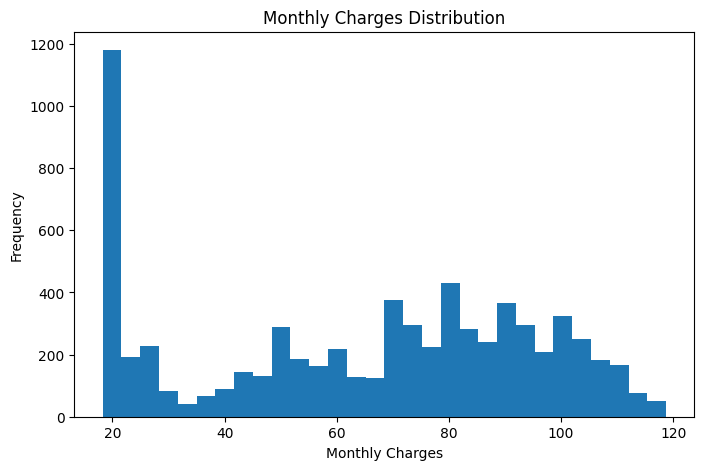

In [7]:
# descriptive statistics for numerical columns

print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())

# plotting MonthlyCharges distribution

plt.figure(figsize=(8,5))

plt.hist(df['MonthlyCharges'], bins=30)

plt.title("Monthly Charges Distribution")

plt.xlabel("Monthly Charges")

plt.ylabel("Frequency")

plt.show()

In [8]:
# encoding categorical columns

le = LabelEncoder()

for column in df.columns:
    
    if df[column].dtype == 'object':
        
        df[column] = le.fit_transform(df[column])

# checking dataset after encoding

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [12]:
# checking remaining data types

print(df.dtypes)

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


In [13]:
# encoding all string columns

le = LabelEncoder()

for column in df.columns:
    
    if df[column].dtype == 'object' or df[column].dtype == 'str':
        
        df[column] = le.fit_transform(df[column])

# checking datatypes again

print(df.dtypes)

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [14]:
# selecting input and target columns

X = df.drop('Churn', axis=1)

y = df['Churn']

# feature scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# checking shapes

print(X_train.shape)

print(X_test.shape)

(5625, 19)
(1407, 19)


In [15]:
# logistic regression model

lr = LogisticRegression()

# training model

lr.fit(X_train, y_train)

# predictions

y_pred_lr = lr.predict(X_test)

# evaluation

print("Logistic Regression Results")

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("Precision:",
      precision_score(y_test, y_pred_lr))

print("Recall:",
      recall_score(y_test, y_pred_lr))

print("F1 Score:",
      f1_score(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.7853589196872779
Precision: 0.6208053691275168
Recall: 0.4946524064171123
F1 Score: 0.5505952380952381


In [16]:
# decision tree model

dt = DecisionTreeClassifier(random_state=42)

# training model

dt.fit(X_train, y_train)

# predictions

y_pred_dt = dt.predict(X_test)

# evaluation

print("Decision Tree Results")

print("Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print("Precision:",
      precision_score(y_test, y_pred_dt))

print("Recall:",
      recall_score(y_test, y_pred_dt))

print("F1 Score:",
      f1_score(y_test, y_pred_dt))

Decision Tree Results
Accuracy: 0.7263681592039801
Precision: 0.486284289276808
Recall: 0.5213903743315508
F1 Score: 0.5032258064516129


In [17]:
# random forest model

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# training model

rf.fit(X_train, y_train)

# predictions

y_pred_rf = rf.predict(X_test)

# evaluation

print("Random Forest Results")

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.7917555081734187
Precision: 0.6431095406360424
Recall: 0.48663101604278075
F1 Score: 0.5540334855403348


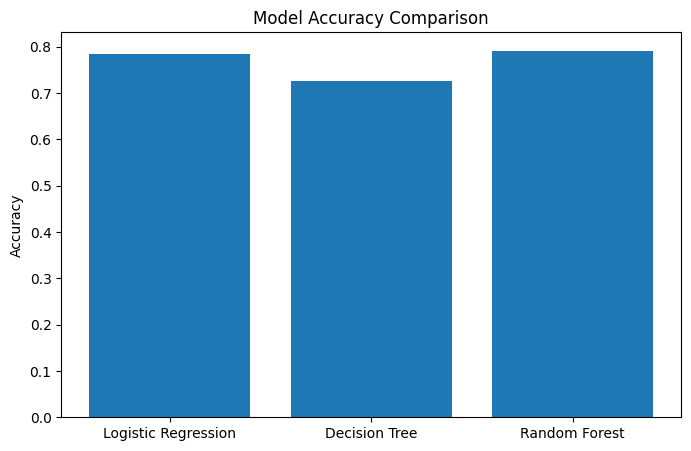

In [18]:
# comparing model accuracies

models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest'
]

accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

# Conclusion

In this project, customer churn prediction was performed using different machine learning classification models.

The dataset was first cleaned and preprocessed by handling missing values, converting data types, encoding categorical variables, and applying feature scaling.

Three machine learning models were trained and compared:

* Logistic Regression
* Decision Tree Classifier
* Random Forest Classifier

Among all models, Random Forest achieved the highest accuracy, while Logistic Regression also performed well with balanced results.

This project helped in understanding:

* data preprocessing
* categorical encoding
* feature scaling
* classification models
* model evaluation
* comparison of machine learning algorithms

The project also demonstrated how machine learning can be used to predict customer churn in telecom services.
